# Classification Examples

Implemented are the following models
- single MLP
- ensemble of MLPs
- repulsive ensemble
- Hamiltonian Monte Carlo
- meanfield VI BNN

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import blackjax
from functools import partial
import matplotlib.pyplot as plt
import shutil
from dataclasses import dataclass
from typing import Callable
from jaxtyping import Array, Float, PRNGKeyArray

from utils.data import gen_data, create_test_grid
from utils.plot import plot_res_det, plot_res_sample
from utils.utils import binary_cross_entropy, uncertainty_decomposition
from utils.kernel import rbf_with_median_heuristic

/home/monkel/00-Projects/2025-VERaIPHY/UQveraiphy/.venv/lib/python3.12/site-packages/jaxopt/_src/osqp.py:299: SyntaxWarning: invalid escape sequence '\m'
  """Operator Splitting Solver for Quadratic Programs.


In [3]:
FONTSIZE = 18
try:
    if shutil.which("latex") is not None:
        plt.rc("text", usetex=True)
        plt.rc(
            "text.latex",
            preamble=r"\usepackage{amsmath}\usepackage[bitstream-charter]{mathdesign}",
        )
        plt.rc("font", family="serif", size=FONTSIZE, serif="Charter")
    else:
        raise RuntimeError("LaTeX not found")
except Exception:
    plt.rc("text", usetex=False)
    plt.rc("font", family="serif", size=FONTSIZE)

plt.rc("axes", titlesize="medium")
colors = [f"C{i}" for i in range(5)]

In [4]:
@dataclass
class Config:
    seed: int = 12345
    # data
    n_obs: int = 500
    resolution: int = 0.03
    noise: float = 0.35
    # grid boundaries
    x_lim: tuple[float, float] = (-2, 3)
    y_lim: tuple[float, float] = (-2, 2.3)
    # MLP hyperparams
    width: int = 32
    depth: int = 2
    n_member: int = 5
    wd: float = 1 / 500
    # training
    n_steps: int = 5_000
    lr: float = 1e-3
    # HMC
    num_samples: int = 500
    num_warmup: int = 500


cfg = Config()
key = jr.PRNGKey(cfg.seed)

In [5]:
data = gen_data(cfg.n_obs, cfg.noise, cfg.seed)
mean, std = data["X"].mean(0), data["X"].std(0)
grid = create_test_grid(cfg.x_lim, cfg.y_lim, cfg.resolution)
norm_grid = (grid - mean) / (std + 1e-6)

## Single MLP

In [6]:
class MLP(eqx.Module):
    model: eqx.nn.MLP

    def __init__(self, key: PRNGKeyArray):
        self.model = eqx.nn.MLP(
            in_size=2,
            out_size=1,
            width_size=cfg.width,
            depth=cfg.depth,
            activation=jax.nn.relu,
            key=key,
        )

    def __call__(self, x: Float[Array, "2"]) -> Float[Array, ""]:
        return self.model(x).squeeze()


def train_mlp(data: dict[str, Array], steps: int, key: PRNGKeyArray) -> MLP:
    model = MLP(key)
    optim = optax.adamw(cfg.lr, weight_decay=cfg.wd)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    def make_step(model, opt_state, x, y):
        def loss_fn(model, x, y):
            logits = jax.vmap(model)(x)
            return binary_cross_entropy(logits, y)

        loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
        updates, opt_state = optim.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    X = data["X"]
    X = (X - X.mean(0)) / (X.std(0) + 1e-6)

    for step in range(steps):
        model, opt_state, loss = make_step(model, opt_state, X, data["label"])
        if step % 500 == 0:
            print(f"Step {step}, Loss: {loss:.4f}")

    return model

In [7]:
key, subkey = jr.split(key)
det_net = train_mlp(data, cfg.n_steps, subkey)

Step 0, Loss: 0.6784
Step 500, Loss: 0.1498
Step 1000, Loss: 0.1308
Step 1500, Loss: 0.1161
Step 2000, Loss: 0.1030
Step 2500, Loss: 0.0949
Step 3000, Loss: 0.0845
Step 3500, Loss: 0.0761
Step 4000, Loss: 0.0687
Step 4500, Loss: 0.0621


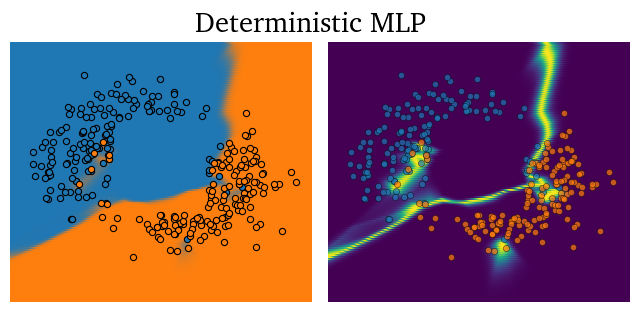

In [8]:
logits = jax.vmap(det_net)(norm_grid)

plot_res_det(
    data, grid, logits, x_lim=cfg.x_lim, y_lim=cfg.y_lim, title="Deterministic MLP"
)
plt.savefig("figures/class_det_mlp.pdf", dpi=300, bbox_inches="tight")

## Ensemble

In [9]:
class Ensemble(eqx.Module):
    n_member: int  # Nr of ensemble members
    ensemble: eqx.Module  # the ensemble

    def __init__(self, net_fun: Callable, n_member: int, key: PRNGKeyArray):
        self.n_member = n_member
        keys = jr.split(key, n_member)
        self.ensemble = eqx.filter_vmap(net_fun)(keys)

    def _get_member(self, idx: int) -> eqx.Module:
        arrays, static = eqx.partition(self.ensemble, eqx.is_array)
        indexed_arrays = jax.tree.map(lambda x: x[idx], arrays)
        return eqx.combine(indexed_arrays, static)

    def __getitem__(self, idx: int) -> eqx.Module:
        """Extract a single member from the ensemble."""
        return self._get_member(idx)

    def __call__(self, x: Array) -> Array:
        """Apply the ensemble forward to a single input."""
        return eqx.filter_vmap(lambda net, x: net(x), in_axes=(eqx.if_array(0), None))(
            self.ensemble, x
        )

    def __len__(self) -> int:
        """Return the number of members in the ensemble."""
        return self.n_member


def train_ensemble(
    data: dict[str, Array], steps: int, key: PRNGKeyArray, n_member: int = 5
) -> Ensemble:
    model = Ensemble(lambda k: MLP(k), n_member=n_member, key=key)
    optim = optax.adamw(cfg.lr, weight_decay=cfg.wd)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    def make_step(model, opt_state, x, y):
        def loss_fn(model, x, y):
            logits = eqx.filter_vmap(model)(x)
            return jax.vmap(binary_cross_entropy, (1, None))(logits, y).sum()

        loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
        updates, opt_state = optim.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    X = data["X"]
    X = (X - X.mean(0)) / (X.std(0) + 1e-6)
    for step in range(steps):
        model, opt_state, loss = make_step(model, opt_state, X, data["label"])
        if step % 500 == 0:
            print(f"Step {step}, Loss: {loss:.4f}")

    return model

In [10]:
ensemble = train_ensemble(data, cfg.n_steps, key, n_member=cfg.n_member)

Step 0, Loss: 3.4986
Step 500, Loss: 0.7989
Step 1000, Loss: 0.6727
Step 1500, Loss: 0.6016
Step 2000, Loss: 0.5324
Step 2500, Loss: 0.4745
Step 3000, Loss: 0.4272
Step 3500, Loss: 0.3837
Step 4000, Loss: 0.3434
Step 4500, Loss: 0.3103


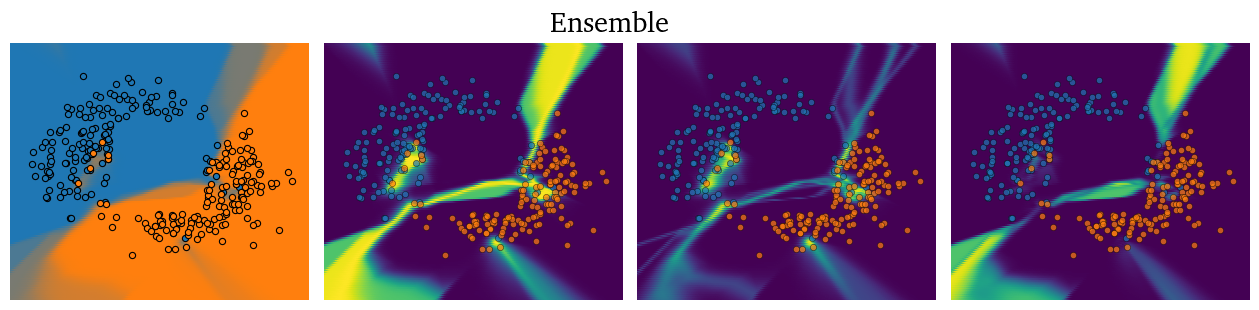

In [11]:
logits = jax.vmap(ensemble)(norm_grid)
plot_res_sample(
    data, grid=grid, x_lim=cfg.x_lim, y_lim=cfg.y_lim, logits=logits, title="Ensemble"
)
plt.savefig("figures/class_det_ens.pdf", dpi=300, bbox_inches="tight")

## Repulsive Ensemble

In [12]:
def train_repulsive_ensemble(
    data: dict[str, Array], steps: int, key: PRNGKeyArray, n_member: int = 5
) -> Ensemble:
    model = Ensemble(lambda k: MLP(k), n_member=n_member, key=key)
    optim = optax.adamw(cfg.lr, weight_decay=cfg.wd)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    def make_step(model, opt_state, x, y):
        def loss_fn(model, x, y):
            logits = eqx.filter_vmap(model)(x)
            bce = jax.vmap(binary_cross_entropy, (1, None))(logits, y)
            k = rbf_with_median_heuristic(bce, jax.lax.stop_gradient(bce))
            return bce.sum() + jnp.sum(
                (k.sum(1) / jax.lax.stop_gradient(k).sum(1) - 1) / x.shape[0], 0
            )

        loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
        updates, opt_state = optim.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    X = data["X"]
    X = (X - X.mean(0)) / (X.std(0) + 1e-6)
    for step in range(steps):
        model, opt_state, loss = make_step(model, opt_state, X, data["label"])
        if step % 500 == 0:
            print(f"Step {step}, Loss: {loss:.4f}")

    return model

In [13]:
rep_ensemble = train_repulsive_ensemble(data, cfg.n_steps, key, n_member=cfg.n_member)

Step 0, Loss: 3.4986
Step 500, Loss: 0.8335
Step 1000, Loss: 0.6861
Step 1500, Loss: 0.6258
Step 2000, Loss: 0.5666
Step 2500, Loss: 0.5112
Step 3000, Loss: 0.4562
Step 3500, Loss: 0.4267
Step 4000, Loss: 0.4153
Step 4500, Loss: 0.4036


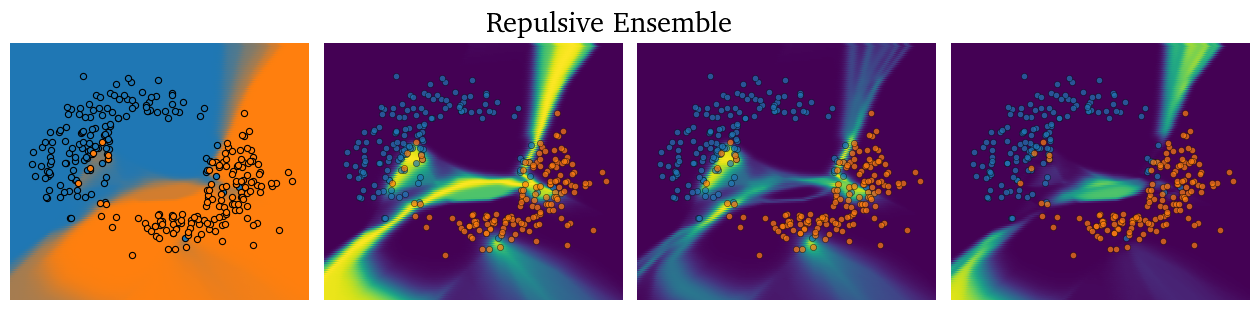

In [14]:
logits = jax.vmap(rep_ensemble)(norm_grid)
plot_res_sample(
    data,
    grid=grid,
    x_lim=cfg.x_lim,
    y_lim=cfg.y_lim,
    logits=logits,
    title="Repulsive Ensemble",
)
plt.savefig("figures/class_det_rep_ens.pdf", dpi=300, bbox_inches="tight")

## HMC

In [15]:
def hmc_bnn(data: dict[str, Array], key: PRNGKeyArray):
    model = MLP(key)
    params, static = eqx.partition(model, eqx.is_array)

    def log_joint(params):
        # Prior log-probability (Standard Normal)
        log_prior = sum(
            jnp.sum(jax.scipy.stats.norm.logpdf(p))
            for p in jax.tree_util.tree_leaves(params)
        )
        # Likelihood log-probability
        model = eqx.combine(params, static)
        logits = jax.vmap(model)(data["X"])
        log_lik = -jnp.sum(optax.sigmoid_binary_cross_entropy(logits, data["label"]))
        return log_prior + log_lik

    # Initialize NUTS
    warmup_key, sample_key = jr.split(key)

    # Warmup
    warmup = blackjax.window_adaptation(blackjax.nuts, log_joint)
    (state, kernel_params), _ = warmup.run(warmup_key, params, num_steps=cfg.num_warmup)

    # Build kernel with adapted parameters
    nuts_kernel = blackjax.nuts(log_joint, **kernel_params)

    def inference_loop(state, key):
        state, info = nuts_kernel.step(key, state)
        return state, state.position

    keys = jr.split(sample_key, cfg.num_samples)
    _, samples = jax.lax.scan(inference_loop, state, keys)

    return samples, static


# Running HMC
key, subkey = jr.split(key)
hmc_samples, hmc_static = hmc_bnn(data, subkey)


@partial(jax.jit, static_argnums=2)
def predict_hmc(grid, samples, static):
    def single_pred(params):
        model = eqx.combine(params, static)
        return jax.nn.sigmoid(jax.vmap(model)(grid))

    all_preds = jax.vmap(single_pred)(samples)
    return all_preds


hmc_preds = predict_hmc(grid, hmc_samples, hmc_static)

In [16]:
pred_entr, aleatoric, epistemic = uncertainty_decomposition(hmc_preds.T)
res = {
    "probs": hmc_preds.mean(0),
    "total": pred_entr,
    "aleatoric": aleatoric,
    "epistemic": epistemic,
}

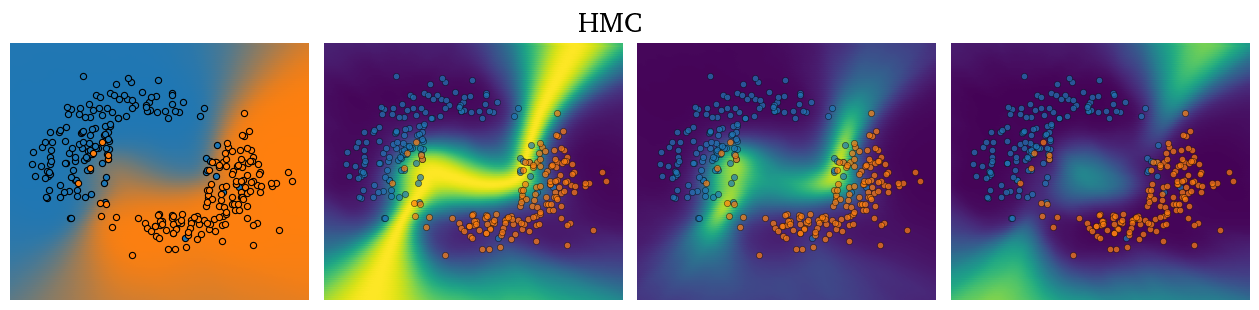

In [17]:
plot_res_sample(
    data, grid=grid, x_lim=cfg.x_lim, y_lim=cfg.y_lim, decomposed=res, title="HMC"
)
plt.savefig("figures/class_hmc.pdf", dpi=300, bbox_inches="tight")

# Mean-field VI BNN

In [18]:
class VariationalLinear(eqx.Module):
    mu: Float[Array, "out_size in_size"]
    rho: Float[Array, "out_size in_size"]
    bias_mu: Float[Array, "out_size"]
    bias_rho: Float[Array, "out_size"]
    in_size: int = eqx.field(static=True)
    out_size: int = eqx.field(static=True)

    def __init__(self, in_size: int, out_size: int, key: PRNGKeyArray):
        k1, k2 = jr.split(key)
        lim = jnp.sqrt(2 / in_size)
        self.in_size, self.out_size = in_size, out_size

        self.mu = jr.uniform(k1, (out_size, in_size), minval=-lim, maxval=lim)
        self.rho = jnp.full((out_size, in_size), -5.0)  # Small initial sigma
        self.bias_mu = jnp.zeros((out_size,))
        self.bias_rho = jnp.full((out_size,), -5.0)

    def __call__(
        self, x: Float[Array, "in_size"], key: PRNGKeyArray
    ) -> Float[Array, "out_size"]:
        k1, k2 = jr.split(key)

        # Reparameterization trick: w = mu + sigma * epsilon
        sigma = jax.nn.softplus(self.rho)
        bias_sigma = jax.nn.softplus(self.bias_rho)

        w = self.mu + sigma * jr.normal(k1, self.mu.shape)
        b = self.bias_mu + bias_sigma * jr.normal(k2, self.bias_mu.shape)
        return w @ x + b

    def kl_divergence(self) -> Float[Array, ""]:
        """KL divergence between N(mu, sigma^2) and N(0, 1) prior."""

        def kl_diag_gaussians(mu, rho):
            sig = jax.nn.softplus(rho)
            return jnp.sum(0.5 * (mu**2 + sig**2 - 1.0 - 2.0 * jnp.log(sig)))

        return kl_diag_gaussians(self.mu, self.rho) + kl_diag_gaussians(
            self.bias_mu, self.bias_rho
        )


class VariationalBNN(eqx.Module):
    layers: list

    def __init__(self, key: PRNGKeyArray):
        keys = jr.split(key, 3)
        self.layers = [
            VariationalLinear(2, cfg.width, keys[0]),
            VariationalLinear(cfg.width, cfg.width, keys[1]),
            VariationalLinear(cfg.width, 1, keys[2]),
        ]

    def __call__(
        self, x: Float[Array, "batch in_size"], key
    ) -> Float[Array, "batch out_size"]:
        keys = jr.split(key, len(self.layers))
        for i, layer in enumerate(self.layers[:-1]):
            x = jax.nn.relu(layer(x, keys[i]))
        return self.layers[-1](x, keys[-1]).squeeze()

    def total_kl(self):
        return sum(
            l.kl_divergence() for l in self.layers if isinstance(l, VariationalLinear)
        )

In [19]:
def train_mfvi(
    X: Float[Array, "batch 2"],
    y: Float[Array, "batch"],
    key: PRNGKeyArray,
    steps: int = 2000,
) -> VariationalBNN:
    model = VariationalBNN(key)
    optim = optax.adam(cfg.lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    X = (X - X.mean(0)) / X.std(0)

    @eqx.filter_jit
    def loss_fn(model, X, y, key):
        keys = jr.split(key, X.shape[0])
        logits = jax.vmap(model)(X, keys)

        log_likelihood = -jnp.mean(optax.sigmoid_binary_cross_entropy(logits, y))
        kl_term = model.total_kl() / len(X)  # Scale KL by dataset size

        # ELBO = Likelihood - KL (we minimize the negative ELBO)
        return -log_likelihood + 0.3 * kl_term

    @eqx.filter_jit
    def step_fn(model, opt_state, X, y, key):
        loss, grads = eqx.filter_value_and_grad(loss_fn)(model, X, y, key)
        updates, opt_state = optim.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    for i in range(steps):
        key, subkey = jr.split(jr.fold_in(key, i))
        model, opt_state, loss = step_fn(model, opt_state, X, y, subkey)
        if i % 500 == 0:
            print(f"Step {i}, Neg ELBO: {loss:.4f}")
    print(f"Step {i}, Neg ELBO: {loss:.4f}")

    return model


# Train the model
key, subkey = jr.split(key)
vi_model = train_mfvi(data["X"], data["label"], subkey, steps=2 * cfg.n_steps)

Step 0, Neg ELBO: 6.1489
Step 500, Neg ELBO: 5.0333
Step 1000, Neg ELBO: 4.4132
Step 1500, Neg ELBO: 3.8170
Step 2000, Neg ELBO: 3.2308
Step 2500, Neg ELBO: 2.6782
Step 3000, Neg ELBO: 2.1393
Step 3500, Neg ELBO: 1.6564
Step 4000, Neg ELBO: 1.2255
Step 4500, Neg ELBO: 0.8975
Step 5000, Neg ELBO: 0.6386
Step 5500, Neg ELBO: 0.4877
Step 6000, Neg ELBO: 0.4319
Step 6500, Neg ELBO: 0.3980
Step 7000, Neg ELBO: 0.3614
Step 7500, Neg ELBO: 0.3538
Step 8000, Neg ELBO: 0.3473
Step 8500, Neg ELBO: 0.3375
Step 9000, Neg ELBO: 0.3741
Step 9500, Neg ELBO: 0.3612
Step 9999, Neg ELBO: 0.3563


In [20]:
keys = jax.random.split(key, 500)
logits = jax.vmap(
    lambda x: jax.vmap(lambda k: vi_model(x, key=k))(keys),
)(norm_grid)

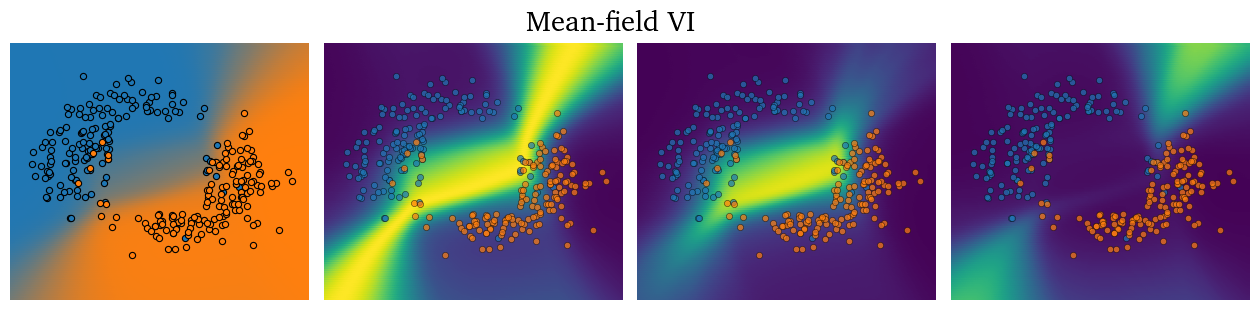

In [21]:
plot_res_sample(
    data,
    grid=grid,
    x_lim=cfg.x_lim,
    y_lim=cfg.y_lim,
    logits=logits,
    title="Mean-field VI",
)
plt.savefig("figures/class_vi.pdf", dpi=300, bbox_inches="tight")

## Diagnostics

Reliability diagram, Brier score, ECE, and conformal prediction sets.

In [22]:
from utils.diagnostics import (
    brier_score,
    expected_calibration_error,
    conformal_prediction_sets,
    plot_reliability_diagram,
    plot_conformal_sets,
)

# Held-out test set (same distribution, different seed)
test_data = gen_data(n_obs=1000, noise=cfg.noise, seed=cfg.seed + 42)
X_test, y_test = test_data["X"], test_data["label"]
X_test_norm = (X_test - mean) / (std + 1e-6)

# Calibration set for conformal prediction
cal_data = gen_data(n_obs=300, noise=cfg.noise, seed=cfg.seed + 99)
X_cal, y_cal = cal_data["X"], cal_data["label"]
X_cal_norm = (X_cal - mean) / (std + 1e-6)

In [23]:
# Predicted probabilities on test and calibration sets
# Note: HMC uses unnormalized inputs; all others use normalized.

# Deterministic
p_det_test = jax.nn.sigmoid(jax.vmap(det_net)(X_test_norm))
p_det_cal = jax.nn.sigmoid(jax.vmap(det_net)(X_cal_norm))

# Ensemble
p_ens_test = jax.nn.sigmoid(jax.vmap(ensemble)(X_test_norm)).mean(1)
p_ens_cal = jax.nn.sigmoid(jax.vmap(ensemble)(X_cal_norm)).mean(1)

# Repulsive Ensemble
p_rep_test = jax.nn.sigmoid(jax.vmap(rep_ensemble)(X_test_norm)).mean(1)
p_rep_cal = jax.nn.sigmoid(jax.vmap(rep_ensemble)(X_cal_norm)).mean(1)

# Mean-field VI (fresh keys for stochastic forward passes)
vi_diag_key = jr.PRNGKey(cfg.seed + 1000)
vi_diag_keys = jr.split(vi_diag_key, 500)
p_vi_test = jax.nn.sigmoid(
    jax.vmap(lambda x: jax.vmap(lambda k: vi_model(x, key=k))(vi_diag_keys))(X_test_norm)
).mean(1)
p_vi_cal = jax.nn.sigmoid(
    jax.vmap(lambda x: jax.vmap(lambda k: vi_model(x, key=k))(vi_diag_keys))(X_cal_norm)
).mean(1)

# HMC — already returns probabilities, uses raw (unnormalized) inputs
p_hmc_test = predict_hmc(X_test, hmc_samples, hmc_static).mean(0)
p_hmc_cal = predict_hmc(X_cal, hmc_samples, hmc_static).mean(0)

methods = {
    "Deterministic": {"test": p_det_test, "cal": p_det_cal},
    "Ensemble": {"test": p_ens_test, "cal": p_ens_cal},
    "Rep. Ensemble": {"test": p_rep_test, "cal": p_rep_cal},
    "Mean-field VI": {"test": p_vi_test, "cal": p_vi_cal},
    "HMC": {"test": p_hmc_test, "cal": p_hmc_cal},
}

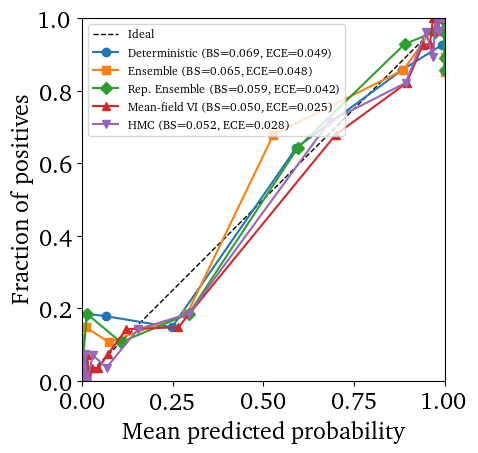

In [44]:
# Reliability diagram with Brier score and ECE in legend
test_probs = {name: m["test"] for name, m in methods.items()}
plot_reliability_diagram(test_probs, y_test, save_path="figures/class_reliability.pdf",n_bins=20)

In [45]:
# Metrics table
print(f"{'Method':20s}  {'Brier':>8s}  {'ECE':>8s}")
print("-" * 42)
for name, m in methods.items():
    bs = brier_score(m["test"], y_test)
    ece = expected_calibration_error(m["test"], y_test, n_bins=20)
    print(f"{name:20s}  {bs:8.4f}  {ece:8.4f}")

Method                   Brier       ECE
------------------------------------------
Deterministic           0.0692    0.0494
Ensemble                0.0647    0.0483
Rep. Ensemble           0.0589    0.0423
Mean-field VI           0.0505    0.0251
HMC                     0.0515    0.0282


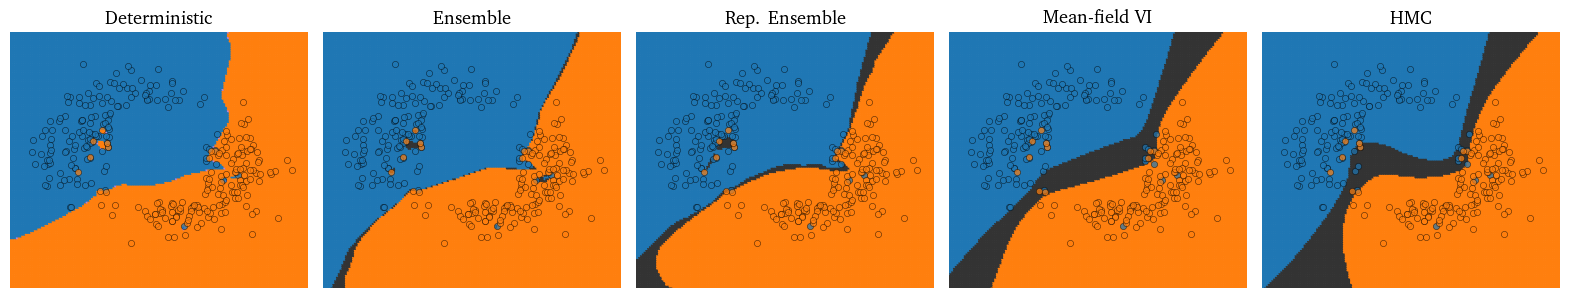

In [47]:
# Conformal prediction set-size heatmaps
# Recompute grid probabilities for each method
grid_probs = {
    "Deterministic": jax.nn.sigmoid(jax.vmap(det_net)(norm_grid)),
    "Ensemble": jax.nn.sigmoid(jax.vmap(ensemble)(norm_grid)).mean(1),
    "Rep. Ensemble": jax.nn.sigmoid(jax.vmap(rep_ensemble)(norm_grid)).mean(1),
    "Mean-field VI": jax.nn.sigmoid(
        jax.vmap(lambda x: jax.vmap(lambda k: vi_model(x, key=k))(vi_diag_keys))(norm_grid)
    ).mean(1),
    "HMC": predict_hmc(grid, hmc_samples, hmc_static).mean(0),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
plt.subplots_adjust(wspace=0.05)

for ax, name in zip(axes, methods):
    sets, q = conformal_prediction_sets(
        methods[name]["cal"], y_cal, grid_probs[name], alpha=0.1
    )
    plot_conformal_sets(
        grid, sets, grid_probs[name], data, cfg.x_lim, cfg.y_lim, title=name, ax=ax
    )

plt.savefig("figures/class_conformal_sets.pdf", dpi=300, bbox_inches="tight")
plt.show()